# Lindsay Foster Notebook
# P3: New Corpus Text Exploration

- Author: [Lindsay Foster](https://github.com/LFoster03/)
- Repository: [nlp-03-text-exploration](https://github.com/LFoster03/nlp-03-text-exploration/)
- Date: 2026-03

Purpose

  Perform exploratory analysis on a new, controlled text corpus.
  Demonstrate how structure emerges from token distributions,
  category comparisons, and co-occurrence patterns.

Analytical Questions

- What tokens dominate each category?
- How do categories differ in vocabulary?
- What words appear in similar contexts?
- What structure is visible before using any models?

Notes

- This module focuses on exploratory analysis (EDA), not modeling.
- Results here prepare for later work with pipelines and embeddings.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**, 
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

See the README.md for more

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

In [81]:
# Section 1 Python cell

# --- Cell 1: Imports & Setup ---

from pathlib import Path
import sys

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt
import polars as pl

# Make plots appear inline in Jupyter
%matplotlib inline

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

In [82]:
# Section 1 Python cell (logger configuration and path setup)
# Add the repo root to sys.path
ROOT_PATH = Path.cwd().parent  # adjust if notebook is nested
sys.path.append(str(ROOT_PATH))

# Configure logger
LOG = get_logger("CI", level="DEBUG")

# Set paths
NOTEBOOKS_PATH = Path.cwd()  # assumes notebook is in notebooks/
ROOT_PATH = NOTEBOOKS_PATH.parent
SCRIPTS_PATH = ROOT_PATH / "scripts"

# Log headers and paths
log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")
log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-25 13:17:47 | INFO | CI | === RUN START ===
2026-03-25 13:17:47 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-25 13:17:47 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-25 13:17:47 | INFO | CI | python=3.14.3
2026-03-25 13:17:47 | INFO | CI | os=Windows 11
2026-03-25 13:17:47 | INFO | CI | shell=powershell
2026-03-25 13:17:47 | INFO | CI | cwd=notebooks copy
2026-03-25 13:17:47 | INFO | CI | github_actions=False
2026-03-25 13:17:47 | INFO | CI | ROOT_PATH = .
2026-03-25 13:17:47 | INFO | CI | NOTEBOOKS_PATH = notebooks copy
2026-03-25 13:17:47 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-25 13:17:47 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

In [83]:
# Section 2 Python cell

corpus = [
    # Books
    {"category": "books", "text": "Books contain stories and information for readers."},
    {"category": "books", "text": "Authors write novels, textbooks, and biographies."},
    {"category": "books", "text": "Readers borrow books and enjoy reading."},
    {"category": "books", "text": "Libraries store books on shelves for access."},
    # Libraries
    {"category": "library", "text": "Libraries provide quiet spaces for studying."},
    {"category": "library", "text": "Librarians help people find books and resources."},
    {"category": "library", "text": "Visitors use computers and check out materials."},
    {"category": "library", "text": "Libraries organize books into categories."},
    # Reading
    {"category": "reading", "text": "Reading improves knowledge and vocabulary."},
    {"category": "reading", "text": "Students read books for school assignments."},
    {"category": "reading", "text": "People read for fun and relaxation."},
    {"category": "reading", "text": "Reading helps develop critical thinking skills."},
]

print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 12 documents.


## Section 3. Tokenize and Clean Text

In [84]:
# Section 3 Python cell

STOP_WORDS = {
    "a",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "for",
    "from",
    "has",
    "have",
    "in",
    "is",
    "it",
    "its",
    "of",
    "on",
    "or",
    "that",
    "the",
    "to",
    "was",
    "were",
    "will",
    "with",
}


# Tokenize function
def tokenize(text: str):
    tokens = text.lower().split()
    return [
        t.strip(".,:;!?()[]\"'") for t in tokens if len(t) > 2 and t not in STOP_WORDS
    ]


# Build token records
records_list = []
for doc in corpus:
    tokens = tokenize(doc["text"])
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

# Create DataFrame
token_df = pl.DataFrame(records_list)
token_df.head(10)

category,token
str,str
"""books""","""books"""
"""books""","""contain"""
"""books""","""stories"""
"""books""","""information"""
"""books""","""readers"""
"""books""","""authors"""
"""books""","""write"""
"""books""","""novels"""
"""books""","""textbooks"""


## Section 4. Compute Global Token Frequencies

In [85]:
# Section 4 Python cell
global_freq_df = token_df.group_by("token").len().sort("len", descending=True)
global_freq_df.head(10)

token,len
str,u32
"""books""",6
"""reading""",3
"""libraries""",3
"""people""",2
"""read""",2
"""readers""",2
"""develop""",1
"""categories""",1
"""biographies""",1


## Section 5. Compute Token Frequencies by Category

In [86]:
# Section 5 Python cell
category_freq_df = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)
category_freq_df.head(12)

category,token,len
str,str,u32
"""reading""","""reading""",2
"""reading""","""read""",2
"""reading""","""school""",1
"""reading""","""assignments""",1
"""reading""","""develop""",1
…,…,…
"""reading""","""knowledge""",1
"""reading""","""relaxation""",1
"""reading""","""students""",1


## Section 6. Identify Top Tokens per Category

In [87]:
# Section 6 Python cell
top_per_category_dict = {}
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list
    print(f"{category.upper()} top tokens: {top_tokens_list}")

READING top tokens: ['reading', 'read', 'school', 'assignments', 'develop']
BOOKS top tokens: ['books', 'readers', 'reading', 'libraries', 'write']
LIBRARY top tokens: ['books', 'libraries', 'librarians', 'organize', 'help']


## Section 7. Analyze Co-occurrence (Context Windows)

Top tokens across all categories:


category,token,len
str,str,u32
"""reading""","""reading""",2
"""reading""","""read""",2
"""reading""","""school""",1
"""library""","""books""",2
"""library""","""libraries""",2
"""library""","""librarians""",1
"""books""","""books""",3
"""books""","""readers""",2
"""books""","""reading""",1


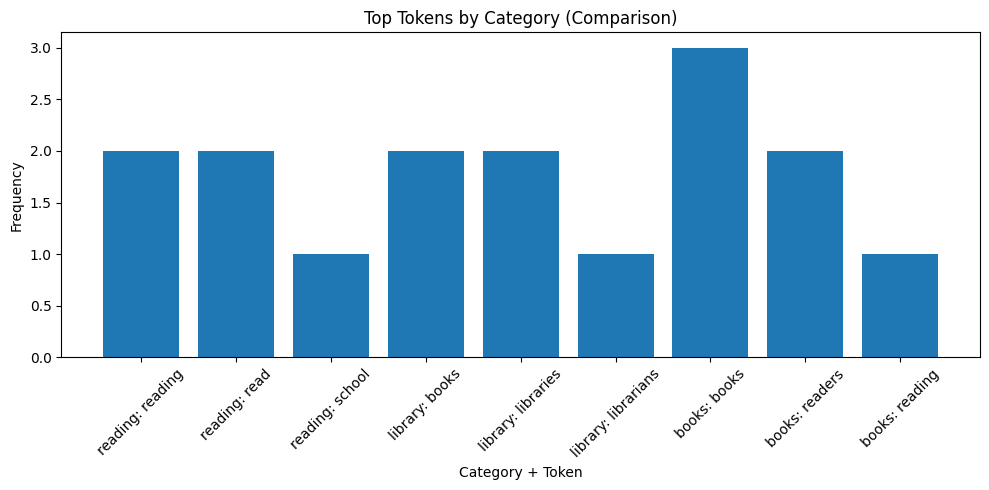

In [88]:
# Section 7 Python cell
top_tokens_all = category_freq_df.group_by("category").head(3)
print("Top tokens across all categories:")
display(top_tokens_all)

# Create combined label for plotting
top_tokens_all = top_tokens_all.with_columns(
    (pl.col("category") + ": " + pl.col("token")).alias("label")
)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(top_tokens_all["label"], top_tokens_all["len"])
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)
plt.title("Top Tokens by Category (Comparison)")
plt.xlabel("Category + Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 8. Create Bigrams (Local Word Pairs) and Compute Frequencies

In [89]:
# Section 8 Python cell

# Bigrams combine each word with the next word in the text.
# This helps us capture local structure: how words are used together,
# not just which words appear individually.

# Bigrams capture pairs of consecutive tokens.

# Define a new empty list to hold the bigram tuples we will create.
bigrams_list: list[tuple[str, str]] = []

# Loop through each document in the corpus, tokenize the text,
# and create bigrams by pairing each token with the next token in the list.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_list.append((tokens[i], tokens[i + 1]))

# Create a DataFrame from the list of bigram tuples,
# where each bigram is represented as a single string with the two tokens separated by a space.
bigram_df: pl.DataFrame = pl.DataFrame(
    {"bigram": [f"{a} {b}" for a, b in bigrams_list]}
)

# Create a new DataFrame that groups the bigrams by their text
# and counts how many times each bigram appears,
# then sorts the results by frequency in descending order.
bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

# Show results
print("Top bigrams:")
print(bigram_freq_df.head(10))

Top bigrams:
shape: (10, 2)
┌──────────────────────┬─────┐
│ bigram               ┆ len │
│ ---                  ┆ --- │
│ str                  ┆ u32 │
╞══════════════════════╪═════╡
│ borrow books         ┆ 1   │
│ check out            ┆ 1   │
│ out materials        ┆ 1   │
│ enjoy reading        ┆ 1   │
│ computers check      ┆ 1   │
│ provide quiet        ┆ 1   │
│ people find          ┆ 1   │
│ libraries store      ┆ 1   │
│ organize books       ┆ 1   │
│ knowledge vocabulary ┆ 1   │
└──────────────────────┴─────┘


## Section 9. Visualize Token Frequencies and Compare Top Tokens Across Categories



Top tokens across all categories:


category,token,len
str,str,u32
"""reading""","""reading""",2
"""reading""","""read""",2
"""reading""","""school""",1
"""library""","""books""",2
"""library""","""libraries""",2
"""library""","""librarians""",1
"""books""","""books""",3
"""books""","""readers""",2
"""books""","""reading""",1


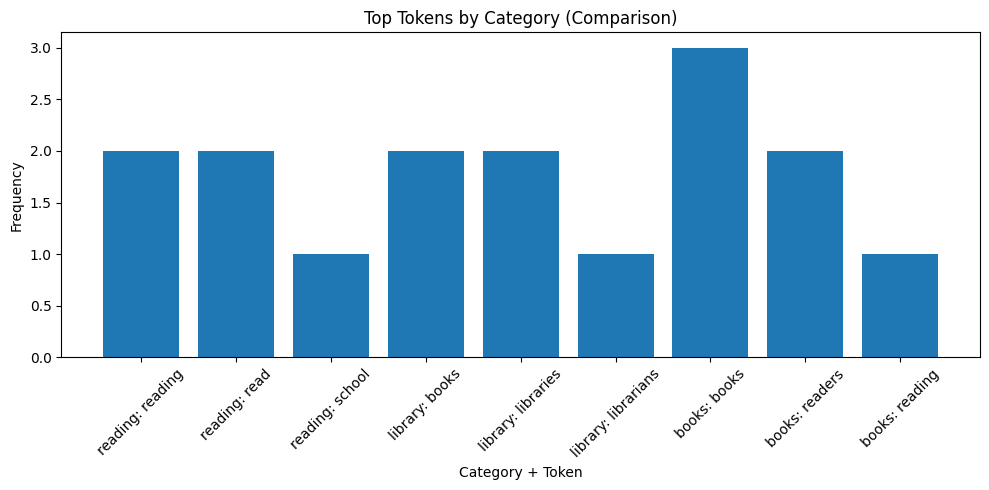

In [90]:
# Section 9.5 New Mod

# Get top 3 tokens per category
top_tokens_all = category_freq_df.group_by("category").head(3)

print("Top tokens across all categories:")
display(top_tokens_all)  # Jupyter-friendly display

# Create a combined label for better plotting
top_tokens_all = top_tokens_all.with_columns(
    (pl.col("category") + ": " + pl.col("token")).alias("label")
)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(top_tokens_all["label"], top_tokens_all["len"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Top Tokens by Category (Comparison)")
plt.xlabel("Category + Token")
plt.ylabel("Frequency")
plt.tight_layout()

# Save the figure as a PNG in docs/images
plt.savefig("../docs/images/Books_Category_Comparison.png", dpi=150)

# Display in notebook
plt.show()

## Section 10. Interpret Results and Identify Patterns

In [91]:
# Section 10 Python cell
print("\nFOSTER GENERAL OBSERVATIONS:")
print("- Tokens cluster by category (books, library, reading).")
print("- The 'books' category focuses on content like authors and readers.")
print("- The 'library' category emphasizes spaces, resources, and services.")
print("- The 'reading' category highlights learning and activities.")
print("- Each category uses different vocabulary, showing clear topic separation.")


FOSTER GENERAL OBSERVATIONS:
- Tokens cluster by category (books, library, reading).
- The 'books' category focuses on content like authors and readers.
- The 'library' category emphasizes spaces, resources, and services.
- The 'reading' category highlights learning and activities.
- Each category uses different vocabulary, showing clear topic separation.


In [92]:
# Final Python cell

LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-25 13:17:47 | INFO | CI | ========================
2026-03-25 13:17:47 | INFO | CI | Notebook executed successfully!
2026-03-25 13:17:47 | INFO | CI | ========================


Notebook executed successfully.
